#HW 2 - Diabetes Data Set

Using - KNN - DT - Random Forest
Soledad Rodriguez

# Step 1 -- Loading Data


In [4]:
import pandas as pd
import numpy as np

from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')

# Path to your CSV in Drive
diabetes_file = '/content/drive/MyDrive/CI345_ML/data/diabetes_prediction_dataset.csv'

diabetes_table = pd.read_csv(diabetes_file)

diabetes_table.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0


#Step 2 -- Data Analysis



In [5]:
#Creates copy of original data set
dt = diabetes_table.copy()

# Show Basic Info
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [6]:
#Show number rows and columns
dt.shape

(100000, 9)

In [7]:
#Show column names
dt.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [8]:
#Show data types
dt.dtypes

,0
gender,object
age,float64
hypertension,int64
heart_disease,int64
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


In [9]:
#Show missing data
dt.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [10]:
#Show descriptive statistics of  age
dt.age.describe()

,age
count,100000.000000
mean,41.885856
std,22.516840
min,0.080000
25%,24.000000
50%,43.000000
75%,60.000000
max,80.000000


In [11]:
#Show descriptive statistics of bmi
dt.bmi.describe()

,bmi
count,100000.000000
mean,27.320767
std,6.636783
min,10.010000
25%,23.630000
50%,27.320000
75%,29.580000
max,95.690000


In [12]:
#Show mean, std, min, max of age and bmi

print("\tAge Statistics")
print("----------------------------")
print("Mean = ", dt.age.mean())
print("Std = ", dt.age.std())
print("Min = ", dt.age.min())
print("Max = ", dt.age.max())

	Age Statistics
----------------------------
Mean =  41.885856
Std =  22.51683987161513
Min =  0.08
Max =  80.0


In [13]:
#Show mean, std, min, max of bmi
print("\tBMI Statistics")
print("----------------------------")
print("Mean = ", dt.bmi.mean())
print("Std = ", dt.bmi.std())
print("Min = ", dt.bmi.min())
print("Max = ", dt.bmi.max())

	BMI Statistics
----------------------------
Mean =  27.3207671
Std =  6.636783416649581
Min =  10.01
Max =  95.69


#Step 3 -- Data Visualization

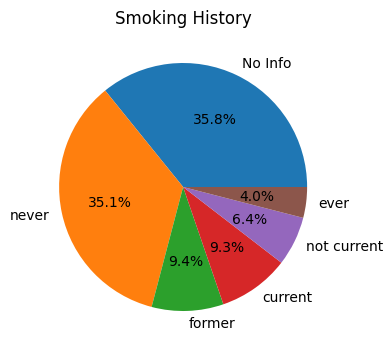

In [14]:
import matplotlib.pyplot as plt

                #Pie Chart -- Smoking History

res = dt['smoking_history'].value_counts()

plt.figure(figsize=(4, 5))
plt.pie(res, labels=res.index, autopct='%1.1f%%')
plt.title('Smoking History')
plt.show()

<Axes: title={'center': 'Numbers of Smoking History'}, xlabel='smoking_history'>

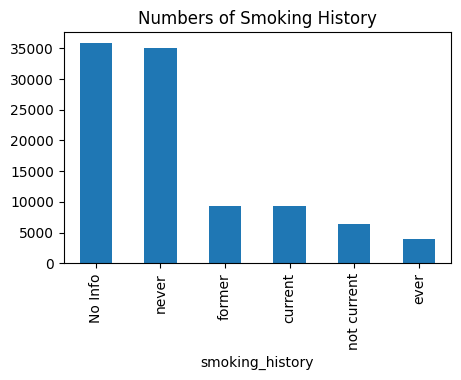

In [15]:
                #Bar Chart -- Smoking History

res = dt['smoking_history'].value_counts()

res.plot(kind = 'bar',title = "Numbers of Smoking History" ,figsize =(5,3))

array([[<Axes: title={'center': 'bmi'}>]], dtype=object)

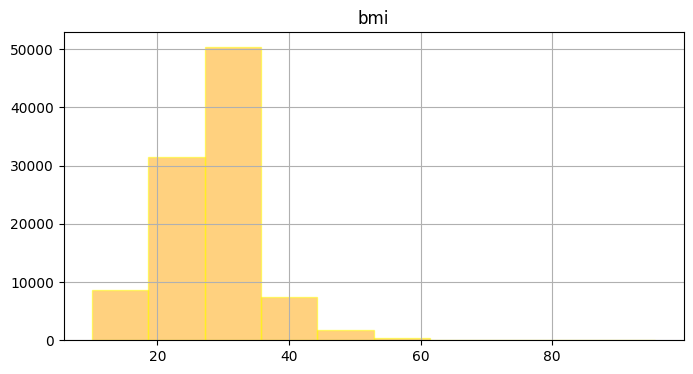

In [16]:
                #Histogram Chart -- BMI

res = dt[['bmi']]

res.hist(alpha = 0.5, color = 'orange', edgecolor = 'yellow',figsize = (8,4))

array([[<Axes: title={'center': 'bmi'}>]], dtype=object)

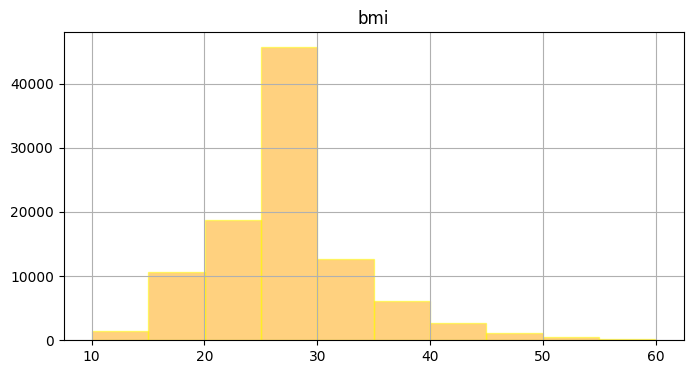

In [29]:
  #Histogram Chart -- Smoking History show bmi < 60



res = dt[dt['bmi'] < 60][['bmi']]

res.hist(alpha = 0.5, color = 'orange', edgecolor = 'yellow',figsize = (8,4))

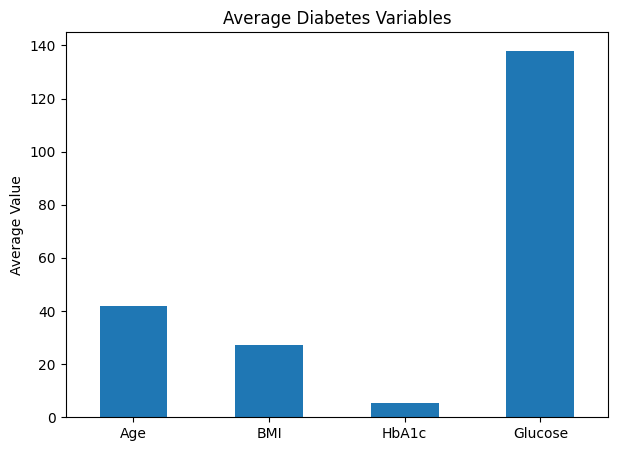

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame
df = pd.DataFrame({
    'Age': dt['age'],
    'BMI': dt['bmi'],
    'HbA1c': dt['HbA1c_level'],
    'Glucose': dt['blood_glucose_level']
})

# Plot average values
df.mean().plot(kind='bar', figsize=(7,5))

plt.title('Average Diabetes Variables')
plt.ylabel('Average Value')
plt.xticks(rotation=0)

plt.show()

<Axes: title={'center': 'Number of Diabetes'}, xlabel='diabetes'>

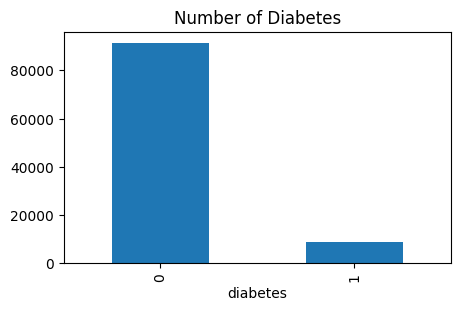

In [48]:
              #Bar Chart -- Diabetes (Target)

res = dt['diabetes'].value_counts()

res.plot(kind = 'bar',title = "Number of Diabetes" ,figsize =(5,3))

# Step 4 -- Data Processing

In [59]:
     #Converting category features into numerical features
                   #Using One-Hot Encoder

from sklearn.preprocessing import OneHotEncoder


# One-hot encode 'gender'
ohe_gender = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_gender = ohe_gender.fit_transform(data[['gender']])
encoded_gender_df = pd.DataFrame(encoded_gender, columns=ohe_gender.get_feature_names_out(['gender']), index=data.index)

# One-hot encode 'smoking_history'
ohe_smoking = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_smoking = ohe_smoking.fit_transform(data[['smoking_history']])
encoded_smoking_df = pd.DataFrame(encoded_smoking, columns=ohe_smoking.get_feature_names_out(['smoking_history']), index=data.index)

# Drop original categorical columns from data and concatenate encoded ones
data_processed = data.drop(columns=['gender', 'smoking_history'])
data_processed = pd.concat([data_processed, encoded_gender_df, encoded_smoking_df], axis=1)



#Step 5 -- Seperating Data and target

In [60]:

print(df.columns)
col = ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level']

data = df[col]

target = df['diabetes']

print(data.shape)
print(target.shape)
print(target.head(2))
data.head(3)


Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')
(100000, 8)
(100000,)
0    0
1    0
Name: diabetes, dtype: int64


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,Female,80.0,0,1,never,25.19,6.6,140
1,Female,54.0,0,0,No Info,27.32,6.6,80
2,Male,28.0,0,0,never,27.32,5.7,158


#Step 6 -- Training Classifiers

In [61]:
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test  = \
train_test_split (data, target, random_state = 13, test_size = 0.4)

    #Review the data and target
print('-- Split Data -- ')
print(data_train.shape)
print(data_test.shape)
print()
print('-- Split Target --')
print(target_train.shape)
print(target_test.shape)

-- Split Data -- 
(60000, 8)
(40000, 8)

-- Split Target --
(60000,)
(40000,)


In [62]:
        # Show training and testing data
print('\t-- Checking Split Data -- ')
print()
print(data_train[:3])
print(data_test[:3])
print()
print('\t-- Checking Target Data -- ')
print()
print(target_train[:3])
print(target_test[:3])

	-- Checking Split Data -- 

       gender   age  hypertension  heart_disease smoking_history    bmi  \
76456  Female  45.0             0              0         No Info  29.20   
20949  Female  29.0             0              0           never  24.89   
72558  Female  19.0             0              0           never  22.75   

       HbA1c_level  blood_glucose_level  
76456          4.8                  126  
20949          3.5                  158  
72558          4.0                   80  
       gender   age  hypertension  heart_disease smoking_history    bmi  \
72031    Male  72.0             0              0         No Info  27.32   
27978    Male  23.0             0              0         No Info  27.32   
55639  Female  80.0             0              1           never  29.24   

       HbA1c_level  blood_glucose_level  
72031          4.0                  200  
27978          4.0                  200  
55639          6.6                  200  

	-- Checking Target Data -- 

76

#Classifier 1 -- KNN

In [63]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

# Step 1 -- Create Classifier loop
for k in range(1, 9, 2):
    print(f'\n\t\t\t\t--- K = {k} ---')
    knn_classifier = KNeighborsClassifier(n_neighbors=k)

    # Step 2 -- Train
    knn_classifier.fit(X=X_train, y=target_train)

    # Step 3 -- Predict
    predicted = knn_classifier.predict(X=X_test)

    # Step 4 -- Report
    print("\n\t----- Classification Report -----")
    print(classification_report(target_test, predicted))

    matrix = confusion_matrix(y_true=target_test, y_pred=predicted)
    print('\t------ Confusion Matrix ------')
    print(matrix)



				--- K = 1 ---

	----- Classification Report -----
              precision    recall  f1-score   support

           0       0.96      0.97      0.97     36593
           1       0.67      0.61      0.64      3407

    accuracy                           0.94     40000
   macro avg       0.82      0.79      0.80     40000
weighted avg       0.94      0.94      0.94     40000

	------ Confusion Matrix ------
[[35572  1021]
 [ 1318  2089]]

				--- K = 3 ---

	----- Classification Report -----
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     36593
           1       0.81      0.56      0.66      3407

    accuracy                           0.95     40000
   macro avg       0.89      0.77      0.82     40000
weighted avg       0.95      0.95      0.95     40000

	------ Confusion Matrix ------
[[36149   444]
 [ 1498  1909]]

				--- K = 5 ---

	----- Classification Report -----
              precision    recall  f1-score   support



#Classifier 2 -- Decision Tree

In [64]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix


# Step 2: Create Decision Tree
dt_classifier = DecisionTreeClassifier(max_depth=3)

# Step 3: Training (Use X_train instead of data_train)
dt_classifier.fit(X=X_train, y=target_train)
print(dt_classifier)

# Step 4: Testing (Use X_test instead of data_test)
predicted = dt_classifier.predict(X=X_test)

# Step 5: Evaluation, Classification Report
print("\n--- Classification Report ---")
print(classification_report(target_test, predicted))

# Step 6: Evaluation, Confusion Matrix
matrix = confusion_matrix(y_true=target_test, y_pred=predicted)
print('--- Confusion Matrix ---')
print(matrix)


DecisionTreeClassifier(max_depth=3)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     36593
           1       1.00      0.67      0.80      3407

    accuracy                           0.97     40000
   macro avg       0.99      0.84      0.90     40000
weighted avg       0.97      0.97      0.97     40000

--- Confusion Matrix ---
[[36593     0]
 [ 1112  2295]]


#Classfier 3 -- Random Forest Classifier


In [65]:
import pandas as pd
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.ensemble import RandomForestClassifier

# Step 1: Create Random Forest Classifier
classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Step 2: Training
classifier.fit(X=X_train, y=target_train)
print(classifier)

# Step 3: Testing (Use X_test instead of data_test)
predicted = classifier.predict(X=X_test)

# Step 4:Classification Report
report = classification_report(target_test, y_pred, zero_division=0)
print("\nClassification Report:")
print(report)

# Step 5: Confusion Matrix
matrix = confusion_matrix(y_true=target_test, y_pred=predicted)
print('--- Confusion Matrix ---')
print(matrix)


RandomForestClassifier(random_state=42)

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     36593
           1       0.95      0.69      0.80      3407

    accuracy                           0.97     40000
   macro avg       0.96      0.84      0.89     40000
weighted avg       0.97      0.97      0.97     40000

--- Confusion Matrix ---
[[36477   116]
 [ 1062  2345]]
